### STEP 1: Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

### STEP 2: Load Dataset

In [3]:
df = pd.read_csv("customer_support_tickets.csv")

### STEP 3: Explore Data

In [8]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['ticket id', 'customer name', 'customer email', 'customer age',
       'customer gender', 'product purchased', 'date of purchase',
       'ticket type', 'ticket subject', 'ticket description', 'ticket status',
       'resolution', 'ticket priority', 'ticket channel',
       'first response time', 'time to resolution',
       'customer satisfaction rating'],
      dtype='object')


### STEP 4: Standardize Column Names

In [9]:
df.columns = df.columns.str.lower().str.strip()
print("Cleaned columns:", df.columns)

Cleaned columns: Index(['ticket id', 'customer name', 'customer email', 'customer age',
       'customer gender', 'product purchased', 'date of purchase',
       'ticket type', 'ticket subject', 'ticket description', 'ticket status',
       'resolution', 'ticket priority', 'ticket channel',
       'first response time', 'time to resolution',
       'customer satisfaction rating'],
      dtype='object')


### STEP 5: Auto Detect Text & Label Columns

In [11]:
# Try to detect columns automatically
text_col = None
label_col = None

for col in df.columns:
    if 'text' in col or 'description' in col or 'issue' in col:
        text_col = col
    if 'category' in col or 'type' in col or 'label' in col:
        label_col = col

print("Detected Text Column:", text_col)
print("Detected Label Column:", label_col)

Detected Text Column: ticket description
Detected Label Column: ticket type


### STEP 6: Select Required Columns

In [13]:
df = df[[text_col, label_col]].copy()
df = df.dropna()

### STEP 7: Text Cleaning Function

In [14]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

### STEP 8: Apply Cleaning

In [15]:
df[text_col] = df[text_col].apply(clean_text)

### STEP 9: Encode Labels

In [16]:
le = LabelEncoder()
df[label_col] = le.fit_transform(df[label_col])

### STEP 10: Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df[text_col], df[label_col], test_size=0.2, random_state=42
)

### STEP 11: TF-IDF Vectorization

In [18]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### STEP 12: Train Model

In [20]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### STEP 13: Predictions

In [21]:
y_pred = model.predict(X_test_vec)

### STEP 14: Evaluation

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.19834710743801653

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.13      0.15       357
           1       0.19      0.20      0.20       327
           2       0.19      0.18      0.19       316
           3       0.21      0.23      0.22       345
           4       0.21      0.24      0.22       349

    accuracy                           0.20      1694
   macro avg       0.20      0.20      0.20      1694
weighted avg       0.20      0.20      0.20      1694



### STEP 15: Confusion Matrix`

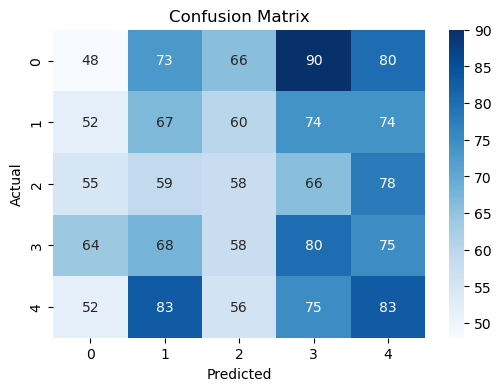

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 16: Prediction + Priority

In [24]:
def predict_ticket(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = model.predict(vec)
    return le.inverse_transform(pred)[0]

def assign_priority(text):
    text = text.lower()
    
    if any(word in text for word in ['urgent', 'asap', 'immediately', 'not working']):
        return "High"
    elif any(word in text for word in ['delay', 'late', 'issue']):
        return "Medium"
    else:
        return "Low"

# Test
print(predict_ticket("Refund not received"))
print(assign_priority("My system is not working urgently"))

Product inquiry
High
